In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import parameters as p
import auxiliary_funcs as af 

# PURPOSE: Test energy scattering. See if correction means correct push towards Maxwellian distribution

tau_o ions = 2123.1766532800625
ZPAR = 233.3333333333333 should match 233.33
ZPERP = 0.03055752047819377


In [2]:
# effective drift and diffusion coefficient for energy scattering
def Asim_x(v_current, reg=True): # REGULARIZE 
    '''
    Asim_x including geometrical correction
    '''
    x, xi = v_current[0], v_current[1] 
    A_a = Aa_x(v_current, reg=reg)

    A_geom = - 1 / (2 * x**4) * af.wb_slp(x) + 2 / (x * np.sqrt(np.pi)) * af.wb_cube_exp(x)

    if reg: 
        reg_geom = 4 / (3 * np.sqrt(np.pi) * x) * af.WB_CUBE
        return A_a + np.where(x < 1e-7, reg_geom, A_geom)
    else:
        return A_a + A_geom


def Aa_x(v_current, reg=True):
    '''
    Asim_x without geometrical correction
    '''
    x, xi = v_current[0], v_current[1] 
    drift = - p.ZPAR / x**2 * af.wparb_slp(x)
    if reg: 
        reg_drift = - p.ZPAR * 4 / (3 * np.sqrt(np.pi)) * x * af.WPARB_CUBE
        return np.where(x < 1e-10, reg_drift, drift)
    else:
        return drift


def D_xx(v_current, reg=True):
    x,xi = v_current[0], v_current[1]  
    coefficient = 1 / (2 * x**3) * af.wb_slp(x)
    if reg:
        return np.where(x < 1e-6, 2 / (3 * np.sqrt(np.pi)) * af.WB_CUBE, coefficient)
    else:
        return coefficient

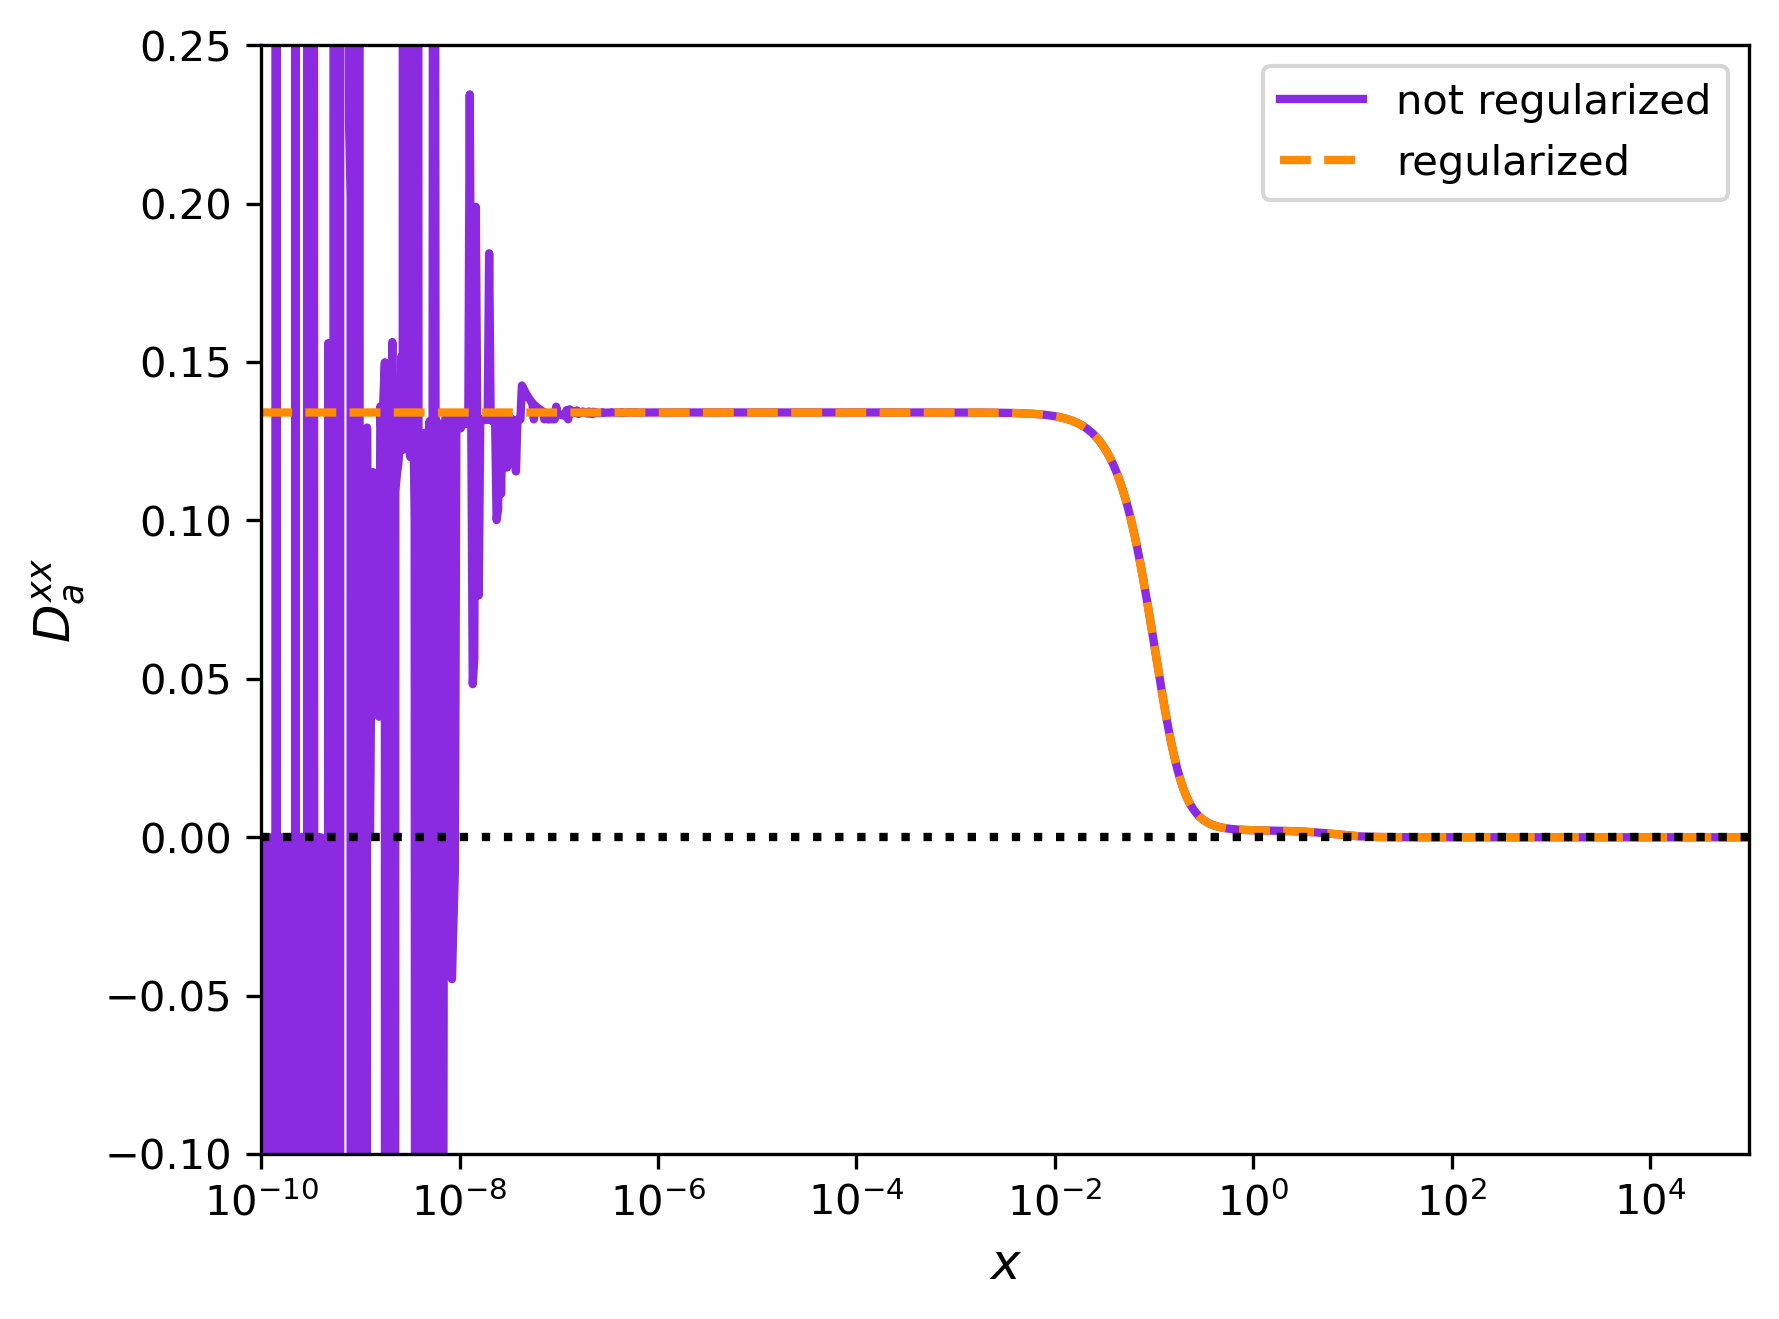

In [9]:
# Plot Dxx 
xvals = np.logspace(-10, 5, 1000)
arr = np.vstack([xvals, np.zeros_like(xvals)])

plt.figure(dpi=300)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(1e-10,1e5)
plt.ylim(-0.1,0.25)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$D^{xx}_a$', fontsize=12)
plt.plot(xvals, D_xx(arr, reg=False), color='blueviolet', label='not regularized', linewidth=2)
plt.plot(xvals, D_xx(arr, reg=True), color='darkorange', label='regularized', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle=':', linewidth=2)
plt.xscale('log')
plt.legend(fontsize=10)
plt.show()

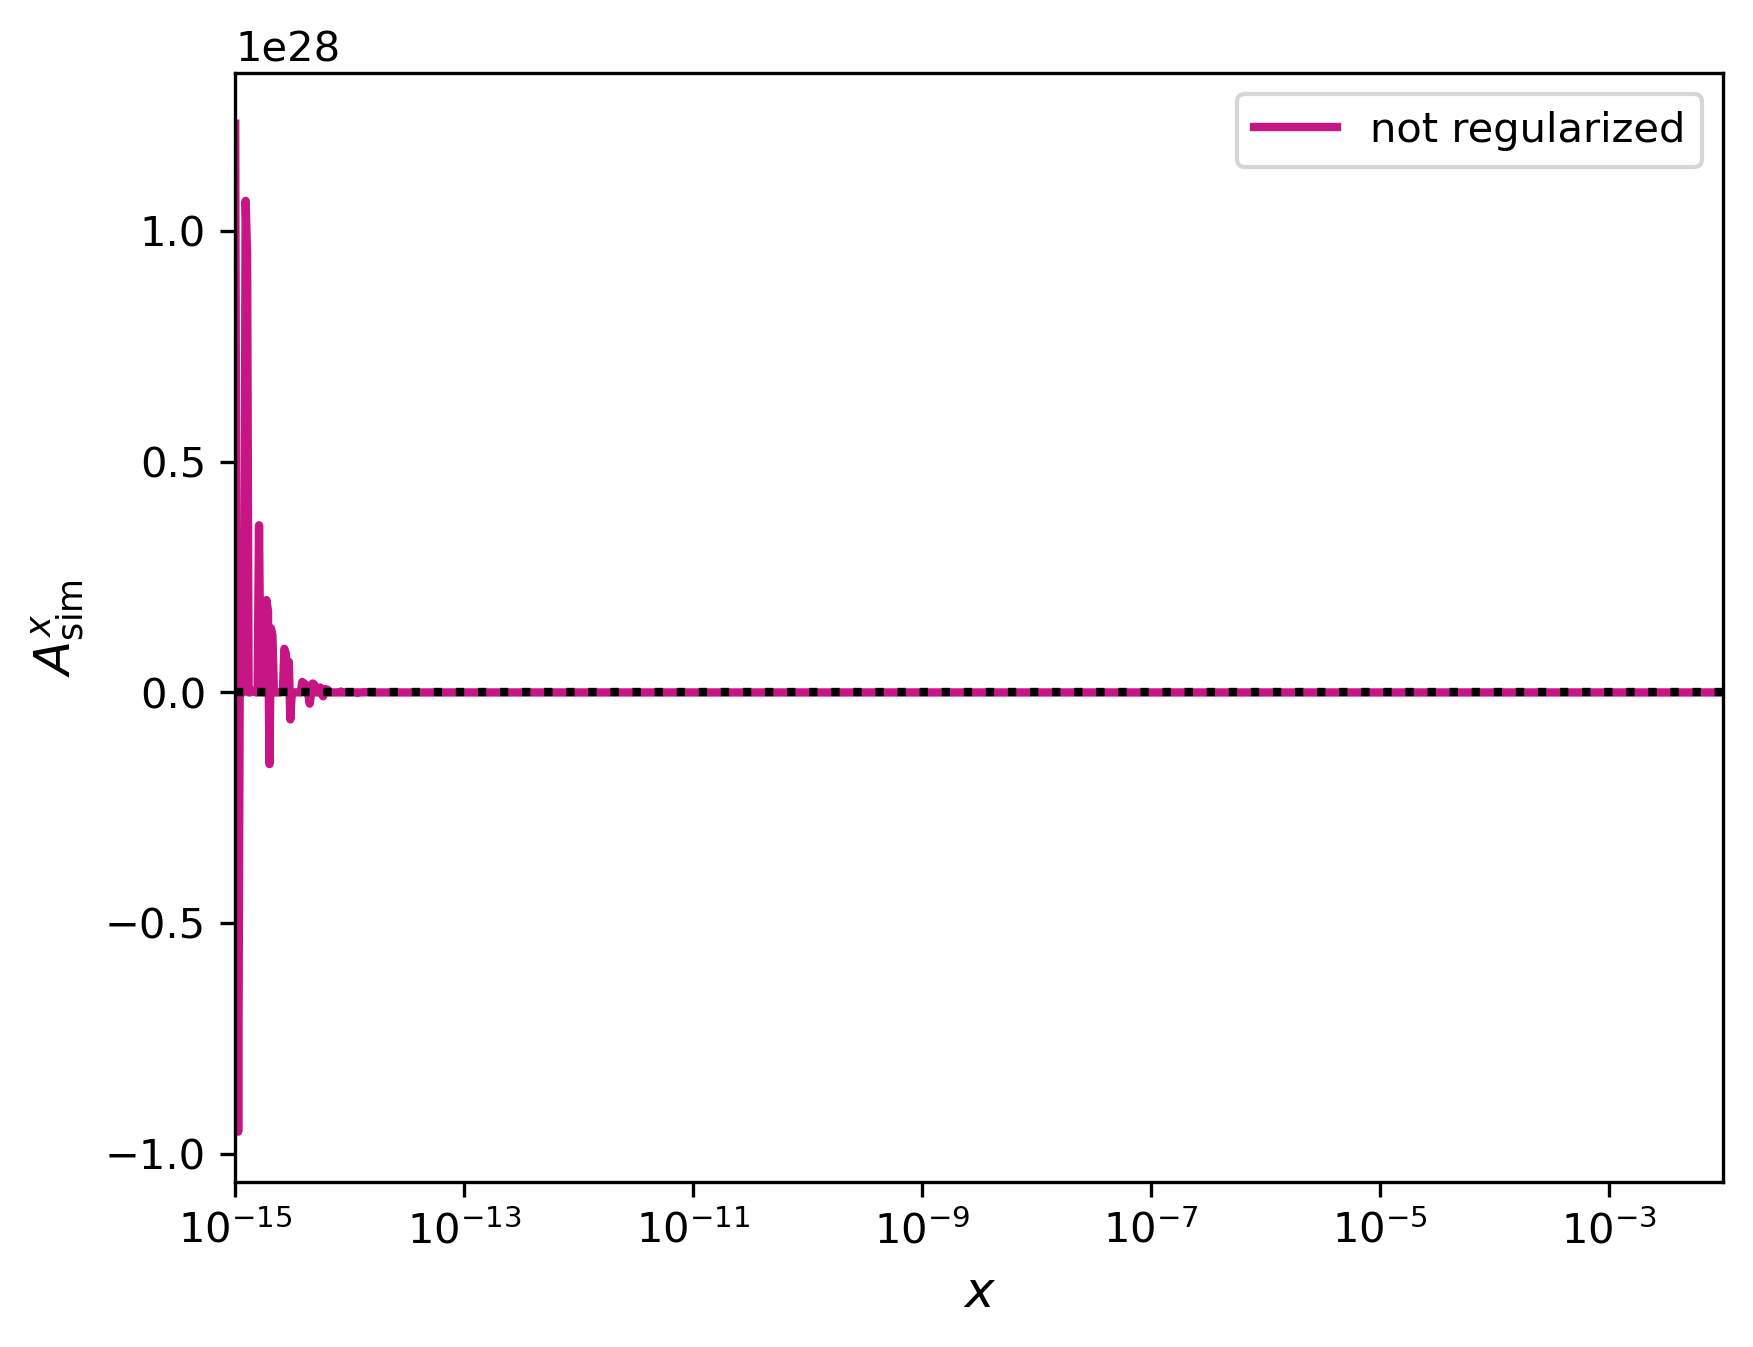

In [15]:
xvals = np.logspace(-15, -2, 1000)
arr = np.vstack([xvals, np.zeros_like(xvals)])

plt.figure(dpi=300)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(1e-15,1e-2)
# plt.ylim(-3.5,1e5)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$A_{\text{sim}}^x$', fontsize=12)
plt.plot(xvals, Asim_x(arr, reg=False), color='mediumvioletred', label='not regularized', linewidth=2)
# plt.plot(xvals, Asim_x(arr, reg=True), color='darkorange', label='regularized', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle=':', linewidth=2)
plt.xscale('log')
# plt.yscale('log')
plt.legend(fontsize=10)
plt.show()

In [ ]:
# functions for running Monte-Carlo 
def singlestep_mc(v_current, Ds_func, As_func, dt):
    Ds_loc = Ds_func(v_current)
    As_loc = As_func(v_current)
    x_current, xi_current = v_current

    dv_D_x = np.random.normal(loc=0, scale=np.sqrt(2*Ds_loc*dt))
    dv_A_x = As_loc * dt
    x_new = x_current + dv_D_x + dv_A_x
    
    while x_new < 0: 
        x_new = - x_new

    v_new = [x_new, xi_current]
    return v_new 


def multistep_mc(v_initial, numsteps, Ds_func, As_func, dt): 
    v_current = v_initial.copy()
    v_store = []
    v_store.append(v_current)

    for i in tqdm(range(numsteps), desc=f"MC steps x = {v_initial[0]}"):
        v_new = singlestep_mc(v_current, Ds_func, As_func, dt)
        # print(f'step {i} v = {v_new}')
        v_store.append(v_new)
        v_current = v_new

    return np.array(v_store)

In [6]:
DT = 1e-5
V_INITIAL = [0.01, 0]
NUMSTEPS = int(1e7)
x_initial, xi_initial = V_INITIAL
print(np.sqrt(2*D_xx(V_INITIAL)*DT))
print(1/np.sqrt(2*D_xx(V_INITIAL)*DT))

0.0016304099563661492
613.3426725562912


In [7]:
result_geom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xx, As_func=Asim_x, dt=DT)

MC steps x = 0.01: 100%|██████████| 10000000/10000000 [05:06<00:00, 32590.72it/s]


In [48]:
result_nogeom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xx, As_func=Aa_x, dt=DT)

MC steps x = 0.01: 100%|██████████| 100000000/100000000 [38:12<00:00, 43611.83it/s] 


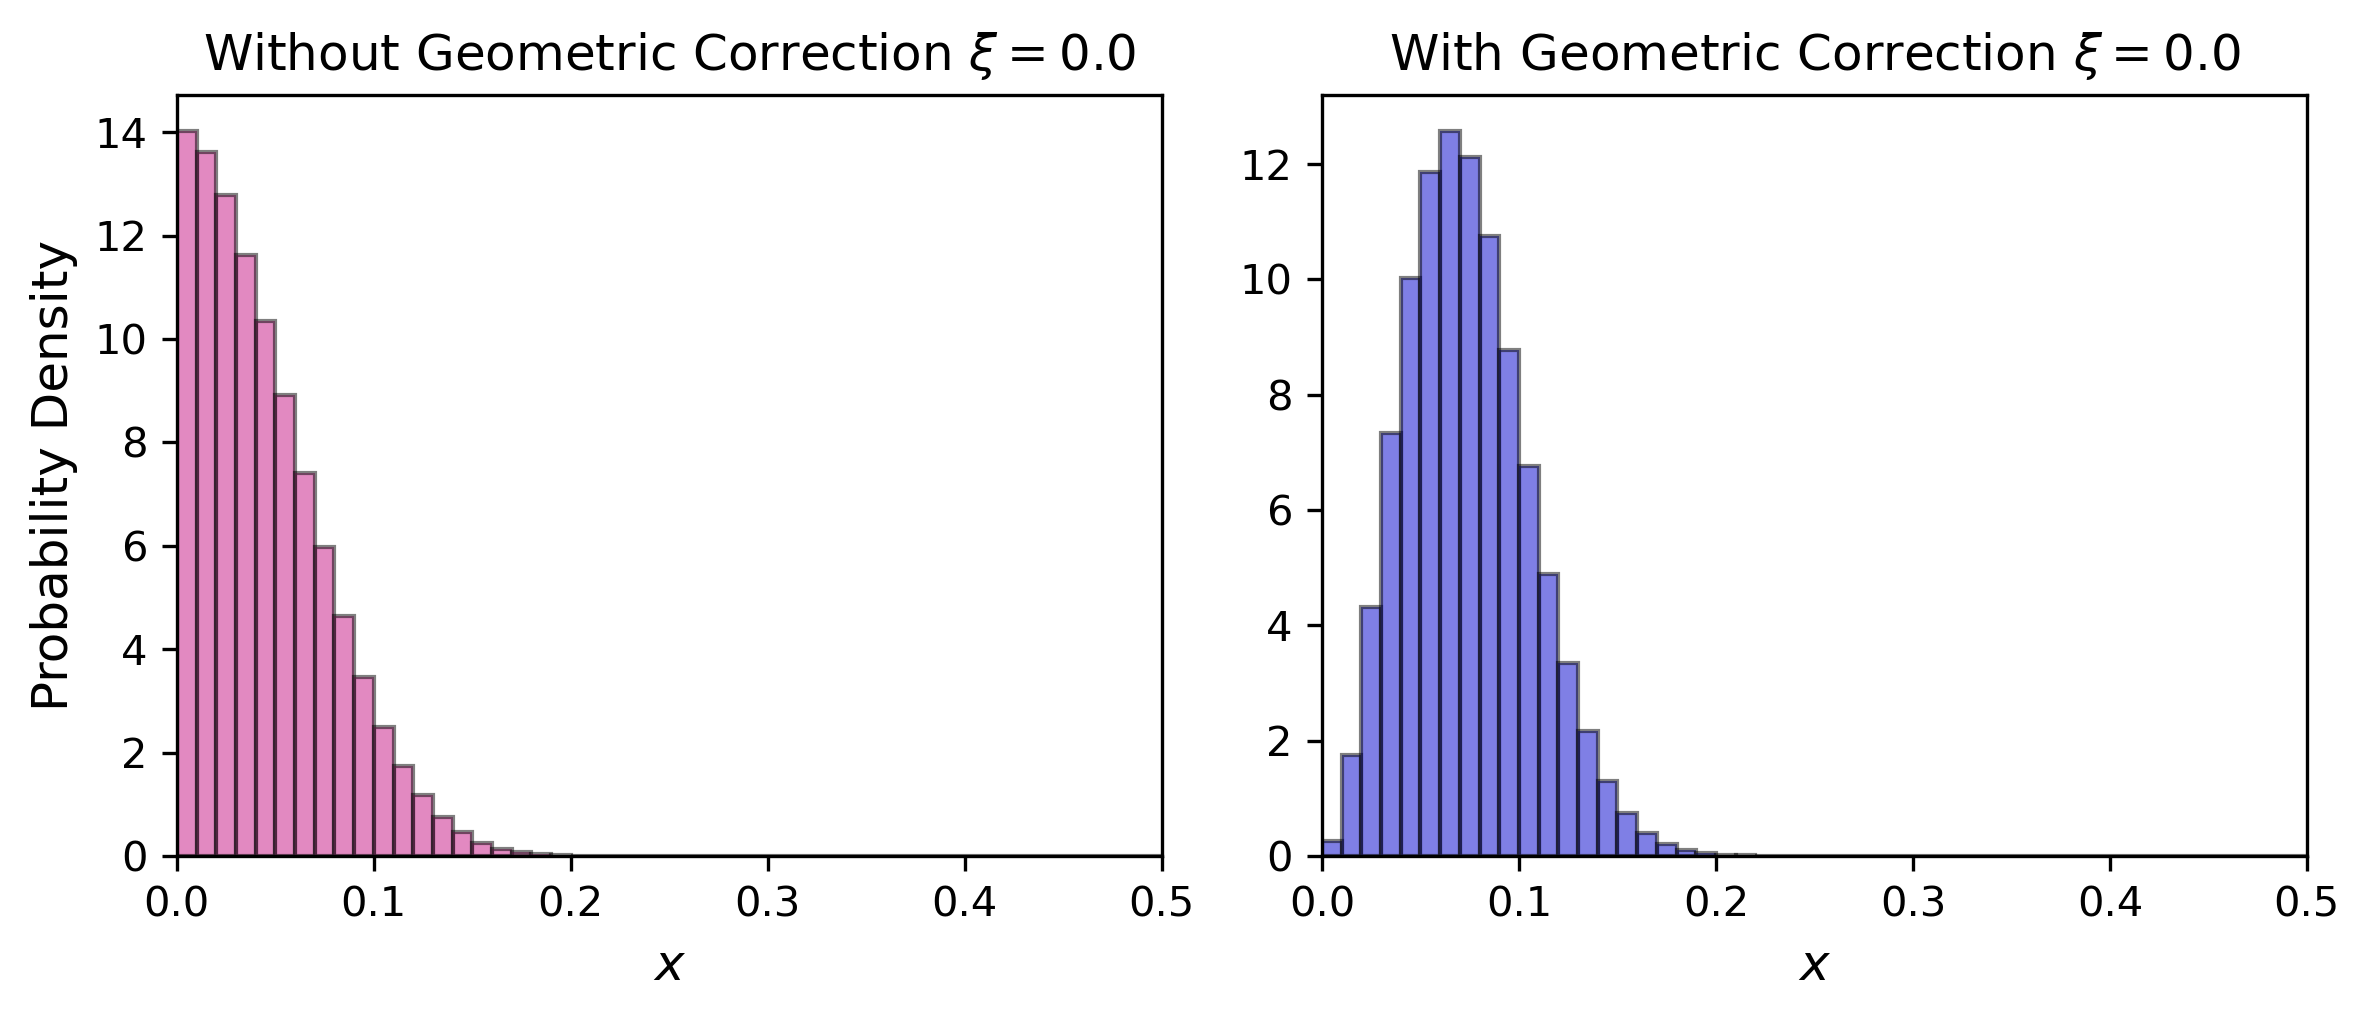

In [ ]:
# plot histogram
xvals_nogeom = result_nogeom[:, 0]
xvals_geom = result_geom[:, 0]

plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(xvals_nogeom, bins=50, range=(0,0.5), density=True, color='mediumvioletred', alpha=0.5, edgecolor='black') # CHANGE BACK TO NOGEOM
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 0.5)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(rf'Without Geometric Correction $\xi={0.0}$', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(xvals_geom, bins=50, range=(0, 0.5), density=True, color='mediumblue', alpha=0.5, edgecolor='black')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 0.5)
plt.xlabel(r'$x$', fontsize=12)
plt.title(rf'With Geometric Correction $\xi={0.0}$', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

xvals_geom = result_geom[:, 0]

hist, bin_edges = np.histogram(xvals_geom, bins=100, range=(0, 0.5), density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def maxwellian_norm(x, a):
    return (4/np.sqrt(np.pi)) * (x**2 / a**3) * np.exp(-x**2 / a**2)

popt, pcov = curve_fit(maxwellian_norm, bin_centers, hist, p0=[0.1])
a_fit = popt[0]

print(f"a = {a_fit}")

a = 0.06579832326838177


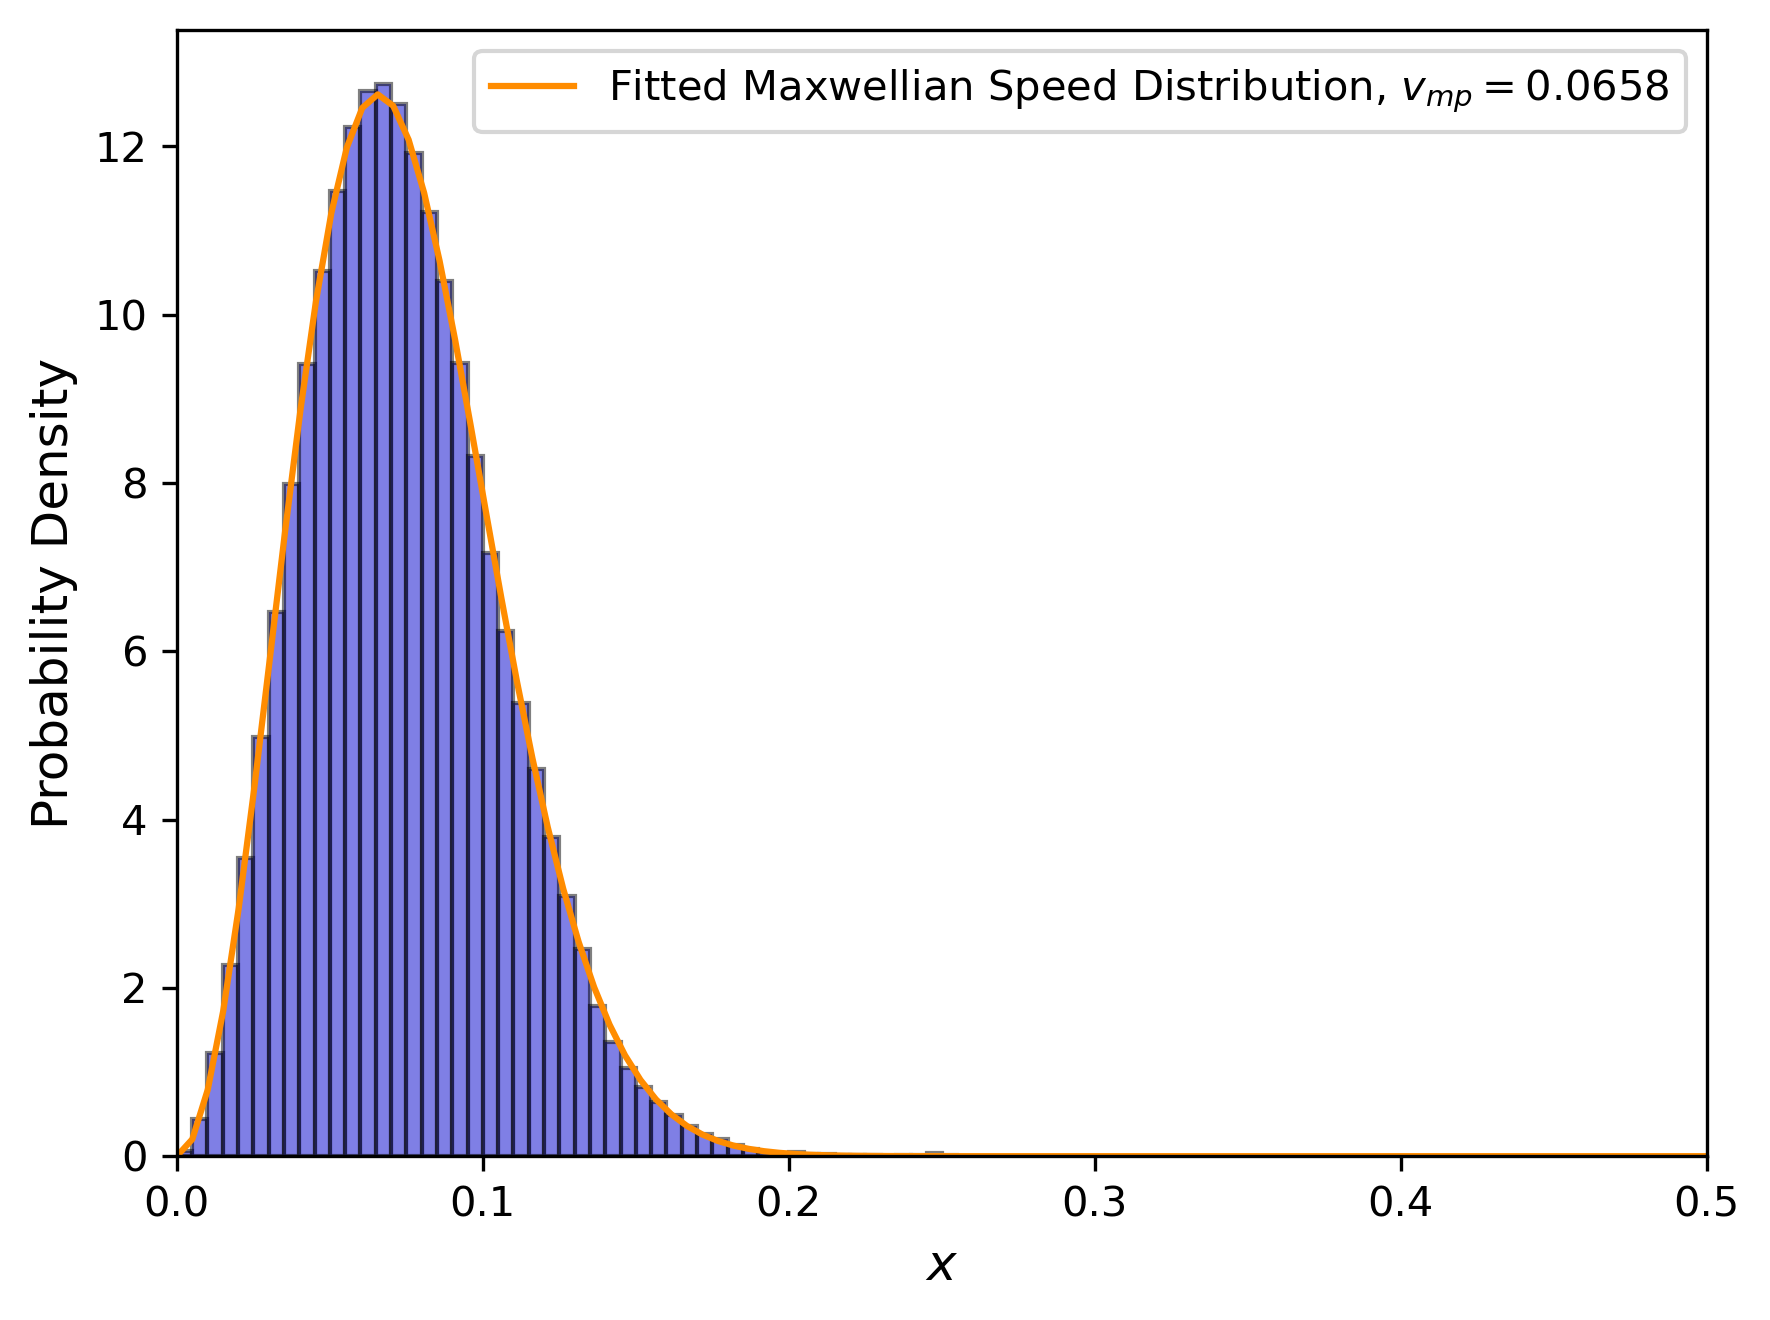

In [28]:
xvals_geom = result_geom[:, 0]

xmax = 0.5
x_line = np.linspace(1e-10, xmax, 100)

plt.figure(figsize=(6,4.5), dpi=300)
plt.hist(xvals_geom, bins=100, range=(0, 0.5), density=True, color='mediumblue', alpha=0.5, edgecolor='black')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 0.5)
plt.xlabel(r'$x$', fontsize=12)
plt.plot(x_line, maxwellian_norm(x_line, a_fit),color='darkorange', label=rf'Fitted Maxwellian Speed Distribution, $v_{{mp}} = {a_fit:.3g}$')
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()